# Patches with Kang Data

## Import Packages

In [1]:
import scanpy as sc
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from ladder.scripts import InterpretableWorkflow
from umap import UMAP

## Helper Functions

In [2]:
def force_aspect(ax, aspect=1):
    """
    Force aspect ratio of a matplotlib axis to be equal. Helper function for plotting.
    Taken from Patches tutorial docs.

    Parameters
    ----------
    ax : matplotlib axis
        The axis to set the aspect ratio for.
    aspect : float, optional
        The aspect ratio to set. Default is 1 (equal).
    """
    im = ax.get_images()
    extent =  im[0].get_extent()
    ax.set_aspect(abs((extent[1]-extent[0])/(extent[3]-extent[2]))/aspect)

def create_umap_df(workflow, model):
    """
    Create a dataframe with UMAP and PCA reductions for plotting.
    Adapted from Patches tutorial docs.

    Parameters
    ----------
    workflow : InterpretableWorkflow
        The fitted InterpretableWorkflow object.
    model : str
        The model type, either "Patches" or "Base".
    
    Returns
    -------
    pd.DataFrame
        A dataframe with UMAP and PCA reductions for plotting.
    """
    # UMAP reducers
    reducer_base = UMAP(n_neighbors=50, min_dist=0.1, metric="correlation", verbose=False, random_state=42)
    reducer = UMAP(n_neighbors=50, min_dist=0.1, metric="correlation", verbose=False, random_state=42)

    match model:
        case "Patches":
            # all data reductions needed for the plots
            base_umap = reducer_base.fit_transform(np.array(workflow.anndata.X.todense()))
            z_umap = reducer.fit_transform(workflow.anndata.obsm['patches_z_latent']) # Z
            w_umap = reducer.fit_transform(workflow.anndata.obsm['patches_w_latent']) # W
            
            w_pca = sc.pp.pca(workflow.anndata.obsm['patches_w_latent'], random_state=42)[:,:2] # W PCA, grab first 2 PCs
            z_pca = sc.pp.pca(workflow.anndata.obsm['patches_z_latent'], random_state=42)[:,:2] # Z PCA, grab first 2 PCs

            # create dataframe and add all reductions
            df = pd.DataFrame(base_umap)
            df.index = workflow.anndata.obs.index
            
            df.columns = ["base_1", "base_2"]
            df["z_umap_1"], df["z_umap_2"] = z_umap[:,0], z_umap[:,1]
            df["w_umap_1"], df["w_umap_2"] = w_umap[:,0], w_umap[:,1]
            df["z_pc_1"], df["z_pc_2"] = z_pca[:,0], z_pca[:,1]
            df["w_pc_1"], df["w_pc_2"] = w_pca[:,0], w_pca[:,1]

        case "Base":
            anndata = workflow.anndata.copy()
            anndata.X = anndata.layers["counts"]
            
            sc.pp.normalize_total(anndata, target_sum=1e4)
            sc.pp.log1p(anndata)
            sc.tl.pca(anndata, svd_solver="arpack")
            
            base_umap = reducer_base.fit_transform(np.array(anndata.X.todense()))
            base_pca = anndata.obsm['X_pca'][:,:2]

            df = pd.DataFrame(base_umap)
            df.index = anndata.obs.index

            df.columns = ["base_umap_1", "base_umap_2"]
            df["base_pc_1"], df["base_pc_2"] = base_pca[:,0], base_pca[:,1]

    # add metadata
    df["group_id"], df["cluster_id"], df["sample_id"] = workflow.anndata.obs["group_id"], workflow.anndata.obs["cluster_id"], workflow.anndata.obs["sample_id"]

    return df

## Load and Prepare Data

In [3]:
# load data
adata = sc.read_h5ad("../../data/kang/01-pro/Kang18.h5ad")
adata.layers["counts"] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 12516 × 4180
    obs: 'cluster_id', 'sample_id', 'group_id', 'sizeFactor', 'cluster_hi', 'cluster_lo'
    var: 'ENSEMBL', 'SYMBOL', 'gene_id', 'bio'
    uns: 'X_name'
    obsm: 'HARMONY', 'PCA', 'TSNE', 'UMAP'
    layers: 'logcounts', 'counts'

## Run Patches in Interpretable Workflow

### Hyperparameters

In [4]:
lr = 0.0098
epochs = 100
minibatch_size = 128
convergence_threshold = 1e-4
convergence_window = 50
random_seed = 42
batch_key = "sample_id"

### Condtion (State) Only - Workflow1

In [5]:
# initialize workflow object
workflow1 = InterpretableWorkflow(
    adata.copy(),
    verbose=True,
    random_seed=random_seed
)

# define the condition classes & batch key to prepare the data
factors = ["group_id"]
workflow1.prep_model(
    factors,
    batch_key=batch_key,
    minibatch_size=minibatch_size,
    model_type="Patches",
    model_args={"ld_normalize" : True},
    optim_args={"lr" : lr})

# run model
workflow1.run_model(max_epochs=epochs, convergence_threshold=convergence_threshold, convergence_window=convergence_window)
workflow1.save_model("../../data/kang/02-scores_patches/Kang18-patches_con")

Initialized workflow to run interpretable model.

Condition classes : ['group_id']
Number of attributes per class : [2]

Initialized Patches model.
Model arguments: {'ld_normalize': True, 'reconstruction': 'ZINB_LD', 'batch_correction': True, 'scale_factor': 1.869019138755981e-06, 'num_labels': 2, 'len_attrs': [2]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.0098, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}
Training initialized for a maximum of 100, with convergence eps 0.0001.
Using device: cpu

Epoch : 0 || Train Loss: 1.1652 // 0.86482 || Test Loss: 0.71704 // 0.6962 || Warmup : False
Epoch : 1 || Train Loss: 0.63539 // 0.70149 || Test Loss: 0.58385 // 0.69671 || Warmup : False
Epoch : 2 || Train Loss: 0.55394 // 0.69511 || Test Loss: 0.53107 // 0.69805 || Warmup : False
Epoch : 3 || Train Loss: 0.52526 // 0.6955 || Test Loss: 0.51418 // 0.6998 || Warmup : False
Epoch 

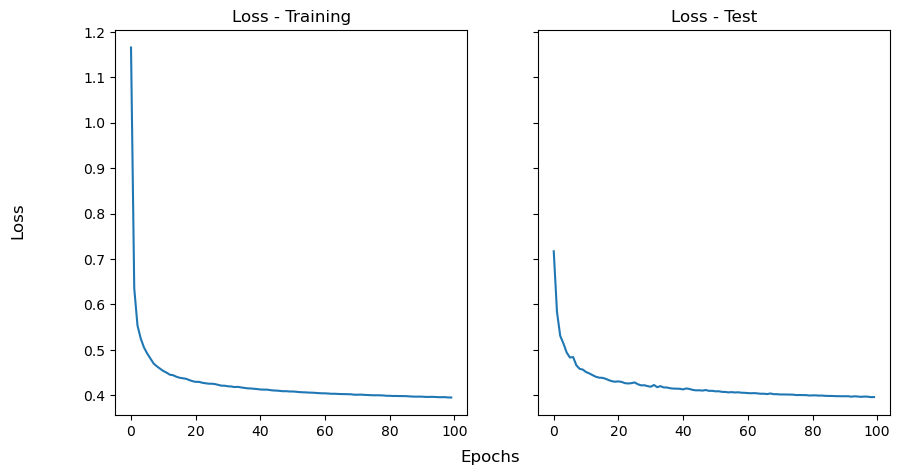

In [6]:
# inspect loss
workflow1.plot_loss()

In [7]:
# save embeddings to adata object
workflow1.write_embeddings()
workflow1.anndata.obsm

Written embeddings to object 'anndata.obsm' under workflow.


AxisArrays with keys: HARMONY, PCA, TSNE, UMAP, patches_w_latent, patches_z_latent

In [8]:
# evaluate run
workflow1.evaluate_reconstruction()

Calculating RMSE ...


100%|██████████| 5/5 [00:10<00:00,  2.03s/it]


Calculating Profile Correlation ...


100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


Calculating 2-Sliced Wasserstein ...


100%|██████████| 5/5 [01:09<00:00, 13.90s/it]


Calculating Chamfer Discrepancy ...


100%|██████████| 5/5 [00:00<00:00, 18.27it/s]

Results
RMSE : 7.259 +- 0.092
Profile Correlation : 0.912 +- 0.001
2-Sliced Wasserstein : 2.874 +- 0.043
Chamfer Discrepancy : 9.262 +- 0.793


{'RMSE': [np.float64(7.259), np.float64(0.092)],
 'Profile Correlation': [np.float64(0.912), np.float64(0.001)],
 '2-Sliced Wasserstein': [np.float64(2.874), np.float64(0.043)],
 'Chamfer Discrepancy': [np.float64(9.262), np.float64(0.793)]}

In [9]:
# get loadings (gene scores)
workflow1.get_conditional_loadings()
workflow1.get_common_loadings()
workflow1.anndata.var

Written condition specific loadings to 'self.anndata.var'.
Written common loadings to 'self.anndata.var'.


,ENSEMBL,SYMBOL,gene_id,bio,ctrl_score_Patches,stim_score_Patches,common_score_Patches
NOC2L,ENSG00000188976,NOC2L,NOC2L,0.006046,0.134616,-0.389392,0.471373
HES4,ENSG00000188290,HES4,HES4,0.017496,-0.104060,-0.163549,-0.504732
ISG15,ENSG00000187608,ISG15,ISG15,0.233506,-0.398758,0.223271,0.078085
TNFRSF18,ENSG00000186891,TNFRSF18,TNFRSF18,0.024728,-0.334771,-0.180962,0.361280
TNFRSF4,ENSG00000186827,TNFRSF4,TNFRSF4,0.019077,0.289331,-0.236610,-0.336046
...,...,...,...,...,...,...,...
PTTG1IP,ENSG00000183255,PTTG1IP,PTTG1IP,-0.006301,0.264843,-0.176217,0.397298
ITGB2,ENSG00000160255,ITGB2,ITGB2,-0.004820,0.048411,-0.181830,-0.196507
FAM207A,ENSG00000160256,FAM207A,FAM207A,0.002081,-0.024886,-0.021024,-0.440598
S100B,ENSG00000160307,S100B,S100B,0.002524,0.413484,0.098476,0.073508


In [10]:
# save loadings to file
workflow1.anndata.var.loc[:, ["ctrl_score_Patches", "stim_score_Patches", "common_score_Patches"]].to_csv(
    "../../data/Kang/02-scores_patches/Kang18_con_loadings.csv"
)

In [11]:
# create dataframes for plotting
df_patches = create_umap_df(workflow1, "Patches")
df_base = create_umap_df(workflow1, "Base")

/Users/michel/miniconda3/envs/type-state/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michel/miniconda3/envs/type-state/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michel/miniconda3/envs/type-state/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


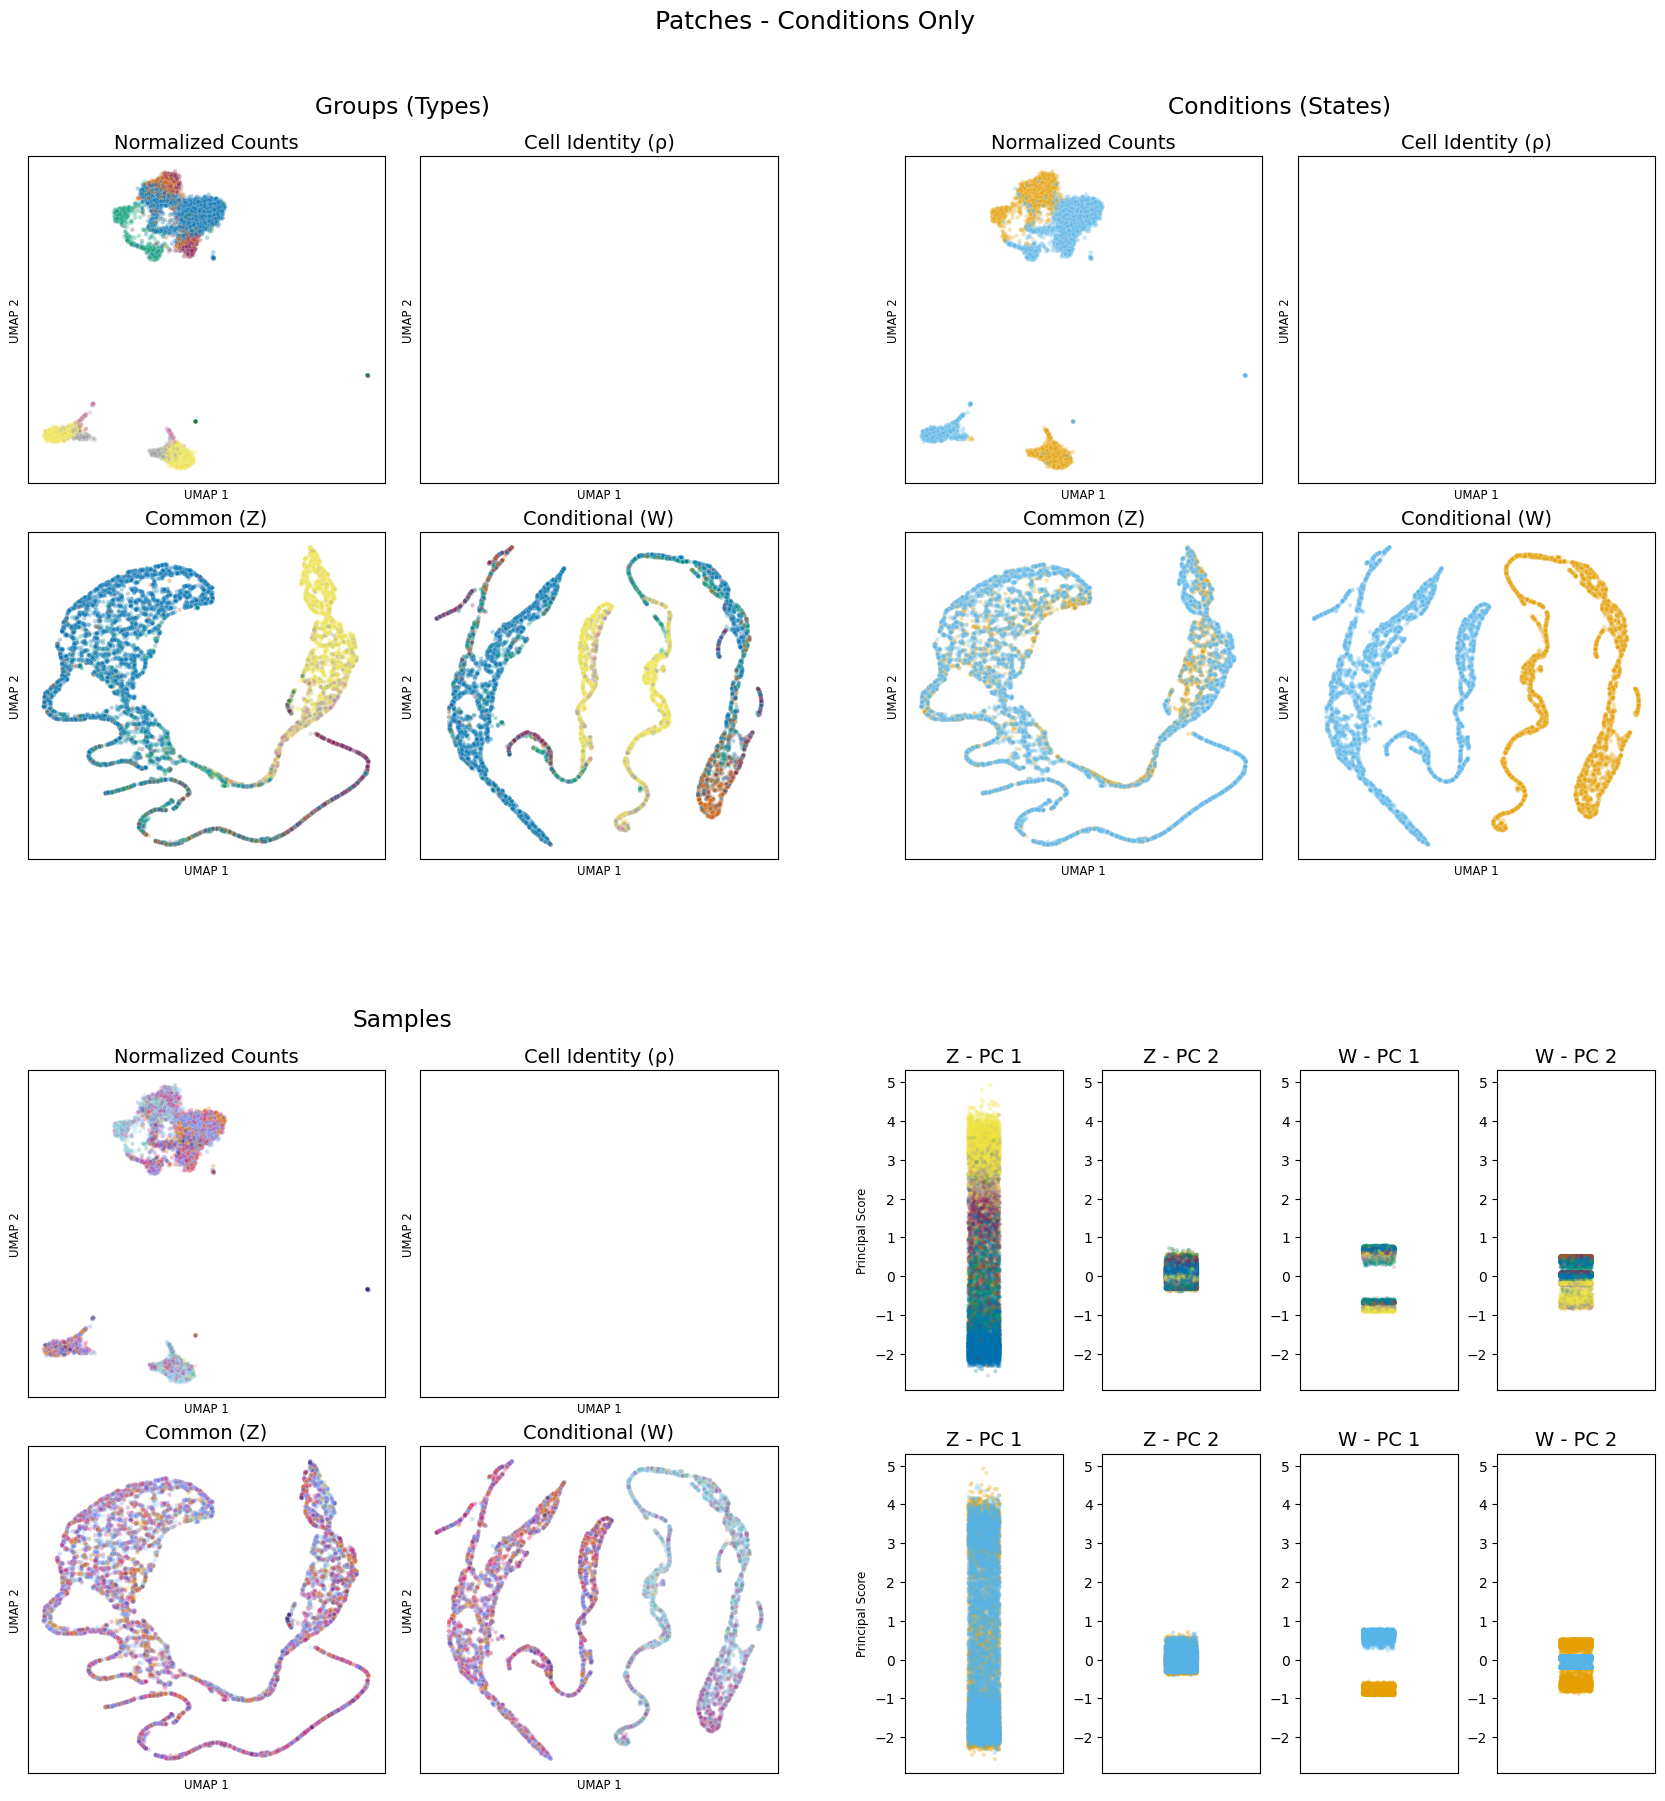

In [12]:
# Figure skeleton (adapted from Patches tutorial docs)


## color palettes
klee_palette = [
    "#8B1E3F",  # Deep Burgundy
    "#3B5998",  # Rich Blue
    "#F4A261",  # Warm Orange
    "#264653",  # Deep Teal
    "#E9C46A",  # Soft Yellow
    "#2A9D8F",  # Muted Green
    "#E76F51",  # Burnt Sienna
    "#D3D9E3",  # Soft Pastel Blue
    "#A8DADC",  # Pale Turquoise
    "#BC4749",  # Warm Cranberry Red
]

klee_palette_masch = [
    "#3B5998",  # Rich Blue
    "#6A994E",  # Fresh Olive Green
    "#F4A261",  # Warm Orange
    "#E9C46A",  # Soft Yellow
    "#2A9D8F",  # Muted Green
    "#E76F51",  # Burnt Sienna
    "#FFC8A2",  # Soft Peach
    "#A8DADC",  # Pale Turquoise
    "#BC4749",  # Warm Cranberry Red
]

cbf_palette = [
    "#E69F00",  # Orange
    "#56B4E9",  # Sky Blue
    "#009E73",  # Bluish Green
    "#F0E442",  # Yellow
    "#0072B2",  # Blue
    "#D55E00",  # Vermillion
    "#CC79A7",  # Reddish Purple
    "#999999",  # Gray
    "#117733",  # Dark Green
    "#882255",  # Wine
    "#44AA99",  # Teal
    "#DDCC77",  # Sand
    "#88CCEE",  # Light Blue
    "#AA4499",  # Magenta
    "#332288",  # Navy
    "#E17C05",  # Burnt Orange
    "#DC267F",  # Pink
    "#648FFF",  # Vivid Blue
    "#785EF0",  # Violet
    "#FE6100",  # Bright Orange
]


## plot parameters
fontsize=14
alpha=0.3
s=10
s_pca=3


## create a figure with a 2x2 grid of subplots
fig = plt.figure(figsize=(21, 21))

## define a GridSpec with a 2x2 layout
gs = gridspec.GridSpec(2, 2, wspace=0.17, hspace = 0.3, figure=fig)

## create subplots for the 2x2 grid
ax = [fig.add_subplot(gs[i//2, i%2]) for i in range(4)]

for subax in ax:
    subax.axis('off')

## define a new GridSpec for axis to split vertically
gs_inner_topleft = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 0], wspace=0.1, hspace=0.15)
gs_inner_topright = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], wspace=0.1, hspace=0.15)
gs_inner_botleft = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1, 0], wspace=0.1, hspace=0.15)
gs_inner_botright = gridspec.GridSpecFromSubplotSpec(2, 4, subplot_spec=gs[1, 1], wspace=0.25)

## create subplots for the inner grid
ax_inner_topleft = [fig.add_subplot(gs_inner_topleft[i//2, i%2]) for i in range(4)]
ax_inner_topright = [fig.add_subplot(gs_inner_topright[i//2, i%2]) for i in range(4)]
ax_inner_botleft = [fig.add_subplot(gs_inner_botleft[i//2, i%2]) for i in range(4)]

## specific for botright
ax_inner_botright = [fig.add_subplot(gs_inner_botright[0,0])]
ax_inner_botright = ax_inner_botright \
+ [
    fig.add_subplot(gs_inner_botright[0,1],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[0,2],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[0,3],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,0],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,1],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,2],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,3],sharey=ax_inner_botright[0]),
]


## UMAP plots

### counts
clu = sns.scatterplot(df_base, x='base_umap_1', y='base_umap_2', ax=ax_inner_topright[0], hue = 'group_id', palette=sns.color_palette(cbf_palette[0:2]), s=s, alpha=alpha)
con = sns.scatterplot(df_base, x='base_umap_1', y='base_umap_2', ax=ax_inner_topleft[0], hue = 'cluster_id', palette=sns.color_palette(cbf_palette[2:10]), s=s, alpha=alpha)
sam = sns.scatterplot(df_base, x='base_umap_1', y='base_umap_2', ax=ax_inner_botleft[0], hue = 'sample_id', palette=sns.color_palette(cbf_palette[10:18]), s=s, alpha=alpha)

### Zs
sns.scatterplot(df_patches, x='z_umap_1', y='z_umap_2', ax=ax_inner_topright[2], hue = 'group_id', palette=sns.color_palette(cbf_palette[0:2]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='z_umap_1', y='z_umap_2', ax=ax_inner_topleft[2], hue = 'cluster_id', palette=sns.color_palette(cbf_palette[2:10]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='z_umap_1', y='z_umap_2', ax=ax_inner_botleft[2], hue = 'sample_id', palette=sns.color_palette(cbf_palette[10:18]), s=s, alpha=alpha, legend=False)

### Ws
sns.scatterplot(df_patches, x='w_umap_1', y='w_umap_2', ax=ax_inner_topright[3], hue = 'group_id', palette=sns.color_palette(cbf_palette[0:2]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='w_umap_1', y='w_umap_2', ax=ax_inner_topleft[3], hue = 'cluster_id', palette=sns.color_palette(cbf_palette[2:10]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='w_umap_1', y='w_umap_2', ax=ax_inner_botleft[3], hue = 'sample_id', palette=sns.color_palette(cbf_palette[10:18]), s=s, alpha=alpha, legend=False)


## PCA plots

### cluster
sns.stripplot(df_patches, y = "z_pc_1", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[0], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[0].axvline(zorder=2, color='black', linestyle = 'dashed')
    
sns.stripplot(df_patches, y = "z_pc_2", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[1], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[1].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_1", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[2], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[2].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_2", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[3], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[3].axvline(zorder=2, color='black', linestyle = 'dashed')


### condition
sns.stripplot(df_patches, y = "z_pc_1", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[4], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[4].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "z_pc_2", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[5], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[5].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_1", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[6], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[6].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_2", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[7], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[7].axvline(zorder=2, color='black', linestyle = 'dashed')


## formatting

for subax in ax_inner_topright:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_yticklabels([])
    subax.set_yticks([])
    subax.set_xlabel('UMAP 1', fontsize=fontsize*0.6)
    subax.set_ylabel('UMAP 2', fontsize=fontsize*0.6)
    try:
        force_aspect(subax)
    except:
        pass

for subax in ax_inner_topleft:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_yticklabels([])
    subax.set_yticks([])
    subax.set_xlabel('UMAP 1', fontsize=fontsize*0.6)
    subax.set_ylabel('UMAP 2', fontsize=fontsize*0.6)
    try:
        force_aspect(subax)
    except:
        pass

for subax in ax_inner_botleft:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_yticklabels([])
    subax.set_yticks([])
    subax.set_xlabel('UMAP 1', fontsize=fontsize*0.6)
    subax.set_ylabel('UMAP 2', fontsize=fontsize*0.6)
    try:
        force_aspect(subax)
    except:
        pass

for subax in ax_inner_botright:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_xlabel('')
    subax.set_ylabel('')

ax_inner_botright[0].set_ylabel('Principal Score', fontsize=fontsize*0.6)
ax_inner_botright[4].set_ylabel('Principal Score', fontsize=fontsize*0.6)

clu_h, clu_l = clu.get_legend_handles_labels() 
con_h, con_l = con.get_legend_handles_labels()
sam_h, sam_l = sam.get_legend_handles_labels()

clu.legend([], frameon=False); con.legend([], frameon=False); sam.legend([], frameon=False)

ax_inner_topleft[0].set_title('Normalized Counts', fontsize=fontsize)
ax_inner_topleft[1].set_title('Cell Identity (ρ)', fontsize=fontsize)
ax_inner_topleft[2].set_title('Common (Z)', fontsize=fontsize)
ax_inner_topleft[3].set_title('Conditional (W)', fontsize=fontsize)

ax_inner_topright[0].set_title('Normalized Counts', fontsize=fontsize)
ax_inner_topright[1].set_title('Cell Identity (ρ)', fontsize=fontsize)
ax_inner_topright[2].set_title('Common (Z)', fontsize=fontsize)
ax_inner_topright[3].set_title('Conditional (W)', fontsize=fontsize)

ax_inner_botleft[0].set_title('Normalized Counts', fontsize=fontsize)
ax_inner_botleft[1].set_title('Cell Identity (ρ)', fontsize=fontsize)
ax_inner_botleft[2].set_title('Common (Z)', fontsize=fontsize)
ax_inner_botleft[3].set_title('Conditional (W)', fontsize=fontsize)

ax_inner_botright[0].set_title('Z - PC 1', fontsize=fontsize)
ax_inner_botright[1].set_title('Z - PC 2', fontsize=fontsize)
ax_inner_botright[2].set_title('W - PC 1', fontsize=fontsize)
ax_inner_botright[3].set_title('W - PC 2', fontsize=fontsize)
ax_inner_botright[4].set_title('Z - PC 1', fontsize=fontsize)
ax_inner_botright[5].set_title('Z - PC 2', fontsize=fontsize)
ax_inner_botright[6].set_title('W - PC 1', fontsize=fontsize)
ax_inner_botright[7].set_title('W - PC 2', fontsize=fontsize)


## set subplot titles
titles = ['Groups (Types)', 'Conditions (States)', 'Samples', '']

for a, t in zip(ax, titles):
    a.set_title(t, y=1.05, fontsize=fontsize*1.2)


## save and show figure
fig.suptitle("Patches - Conditions Only", fontsize=18, y=0.95)
plt.savefig("../../outs/kang/Kang18-patches_con.png", dpi=300, bbox_inches='tight')
plt.show()

### Group (Type) + Condtion (State) - Workflow2

In [13]:
# initialize workflow object
workflow2 = InterpretableWorkflow(
    adata.copy(),
    verbose=True,
    random_seed=random_seed
)

# define the condition classes & batch key to prepare the data
factors = ["cluster_id", "group_id"]
workflow2.prep_model(
    factors,
    batch_key=batch_key,
    minibatch_size=minibatch_size,
    model_type="Patches",
    model_args={"ld_normalize" : True},
    optim_args={"lr" : lr})

# run model
workflow2.run_model(max_epochs=epochs, convergence_threshold=convergence_threshold, convergence_window=convergence_window)
workflow2.save_model("../../data/kang/02-scores_patches/Kang18-patches_clu_con")

Initialized workflow to run interpretable model.

Condition classes : ['cluster_id', 'group_id']
Number of attributes per class : [8, 2]

Initialized Patches model.
Model arguments: {'ld_normalize': True, 'reconstruction': 'ZINB_LD', 'batch_correction': True, 'scale_factor': 1.869019138755981e-06, 'num_labels': 10, 'len_attrs': [8, 2]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.0098, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}
Training initialized for a maximum of 100, with convergence eps 0.0001.
Using device: cpu

Epoch : 0 || Train Loss: 1.19903 // 2.97696 || Test Loss: 0.95295 // 3.05283 || Warmup : False
Epoch : 1 || Train Loss: 0.71717 // 2.37721 || Test Loss: 0.62367 // 2.4862 || Warmup : False
Epoch : 2 || Train Loss: 0.58499 // 2.27391 || Test Loss: 0.59759 // 2.06745 || Warmup : False
Epoch : 3 || Train Loss: 0.55462 // 2.19946 || Test Loss: 0.5198 // 2.52148 |

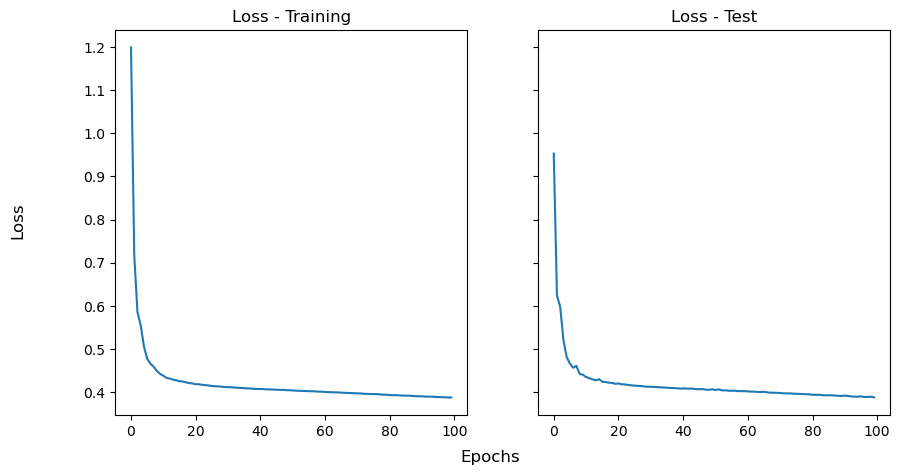

In [14]:
# inspect loss
workflow2.plot_loss()

In [15]:
# save embeddings to adata object
workflow2.write_embeddings()
workflow2.anndata.obsm

Written embeddings to object 'anndata.obsm' under workflow.


AxisArrays with keys: HARMONY, PCA, TSNE, UMAP, patches_w_latent, patches_z_latent

In [16]:
# evaluate run
workflow2.evaluate_reconstruction()

Calculating RMSE ...


100%|██████████| 5/5 [00:11<00:00,  2.26s/it]


Calculating Profile Correlation ...


100%|██████████| 5/5 [00:11<00:00,  2.26s/it]


Calculating 2-Sliced Wasserstein ...


100%|██████████| 5/5 [01:10<00:00, 14.09s/it]


Calculating Chamfer Discrepancy ...


100%|██████████| 5/5 [00:00<00:00, 19.97it/s]

Results
RMSE : 8.513 +- 0.09
Profile Correlation : 0.893 +- 0.001
2-Sliced Wasserstein : 3.446 +- 0.058
Chamfer Discrepancy : 17.92 +- 1.113


{'RMSE': [np.float64(8.513), np.float64(0.09)],
 'Profile Correlation': [np.float64(0.893), np.float64(0.001)],
 '2-Sliced Wasserstein': [np.float64(3.446), np.float64(0.058)],
 'Chamfer Discrepancy': [np.float64(17.92), np.float64(1.113)]}

In [17]:
# get loadings (gene scores)
workflow2.get_conditional_loadings()
workflow2.get_common_loadings()
workflow2.anndata.var

Written condition specific loadings to 'self.anndata.var'.
Written common loadings to 'self.anndata.var'.


,ENSEMBL,SYMBOL,gene_id,bio,B cells_score_Patches,CD14+ Monocytes_score_Patches,CD4 T cells_score_Patches,CD8 T cells_score_Patches,Dendritic cells_score_Patches,FCGR3A+ Monocytes_score_Patches,Megakaryocytes_score_Patches,NK cells_score_Patches,ctrl_score_Patches,stim_score_Patches,common_score_Patches
NOC2L,ENSG00000188976,NOC2L,NOC2L,0.006046,0.037563,0.061731,-0.036973,0.214337,0.110026,0.004627,-0.173192,0.121847,-0.164341,-0.033919,0.085261
HES4,ENSG00000188290,HES4,HES4,0.017496,0.200302,-0.098269,-0.278239,0.147652,0.083826,-0.006486,0.027667,0.152362,0.004427,0.263210,0.185376
ISG15,ENSG00000187608,ISG15,ISG15,0.233506,-0.102527,-0.075301,-0.152210,-0.138146,0.134378,0.202807,0.032589,0.013328,0.028985,-0.007806,-0.522028
TNFRSF18,ENSG00000186891,TNFRSF18,TNFRSF18,0.024728,-0.208906,-0.184393,-0.323094,0.231161,-0.000723,-0.087449,0.106507,0.299107,0.073625,-0.126384,0.044843
TNFRSF4,ENSG00000186827,TNFRSF4,TNFRSF4,0.019077,0.058955,0.076048,0.141706,0.123359,0.192904,0.021779,-0.192632,0.062676,0.098227,0.168093,0.286513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTTG1IP,ENSG00000183255,PTTG1IP,PTTG1IP,-0.006301,-0.142505,-0.044490,0.084524,-0.030279,0.064319,0.027324,0.114495,-0.246577,-0.151515,0.009676,0.466756
ITGB2,ENSG00000160255,ITGB2,ITGB2,-0.004820,0.098599,-0.077253,-0.107182,0.156675,-0.199443,-0.209666,0.013842,-0.056039,0.024067,-0.030978,-0.336711
FAM207A,ENSG00000160256,FAM207A,FAM207A,0.002081,0.132173,0.018562,0.149020,0.002952,0.111406,-0.113367,-0.283716,0.040970,0.166148,0.160934,0.062667
S100B,ENSG00000160307,S100B,S100B,0.002524,-0.117241,0.066668,0.209683,-0.054175,0.251758,0.041732,-0.034528,-0.082607,0.138969,-0.078624,0.267642


In [18]:
# save loadings to file
workflow2.anndata.var.iloc[:, 4:].to_csv(
    "../../data/Kang/02-scores_patches/Kang18_clu_con_loadings.csv"
)

In [19]:
# create dataframes for plotting
df_patches = create_umap_df(workflow2, "Patches")
df_base = create_umap_df(workflow2, "Base")

/Users/michel/miniconda3/envs/type-state/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michel/miniconda3/envs/type-state/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michel/miniconda3/envs/type-state/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


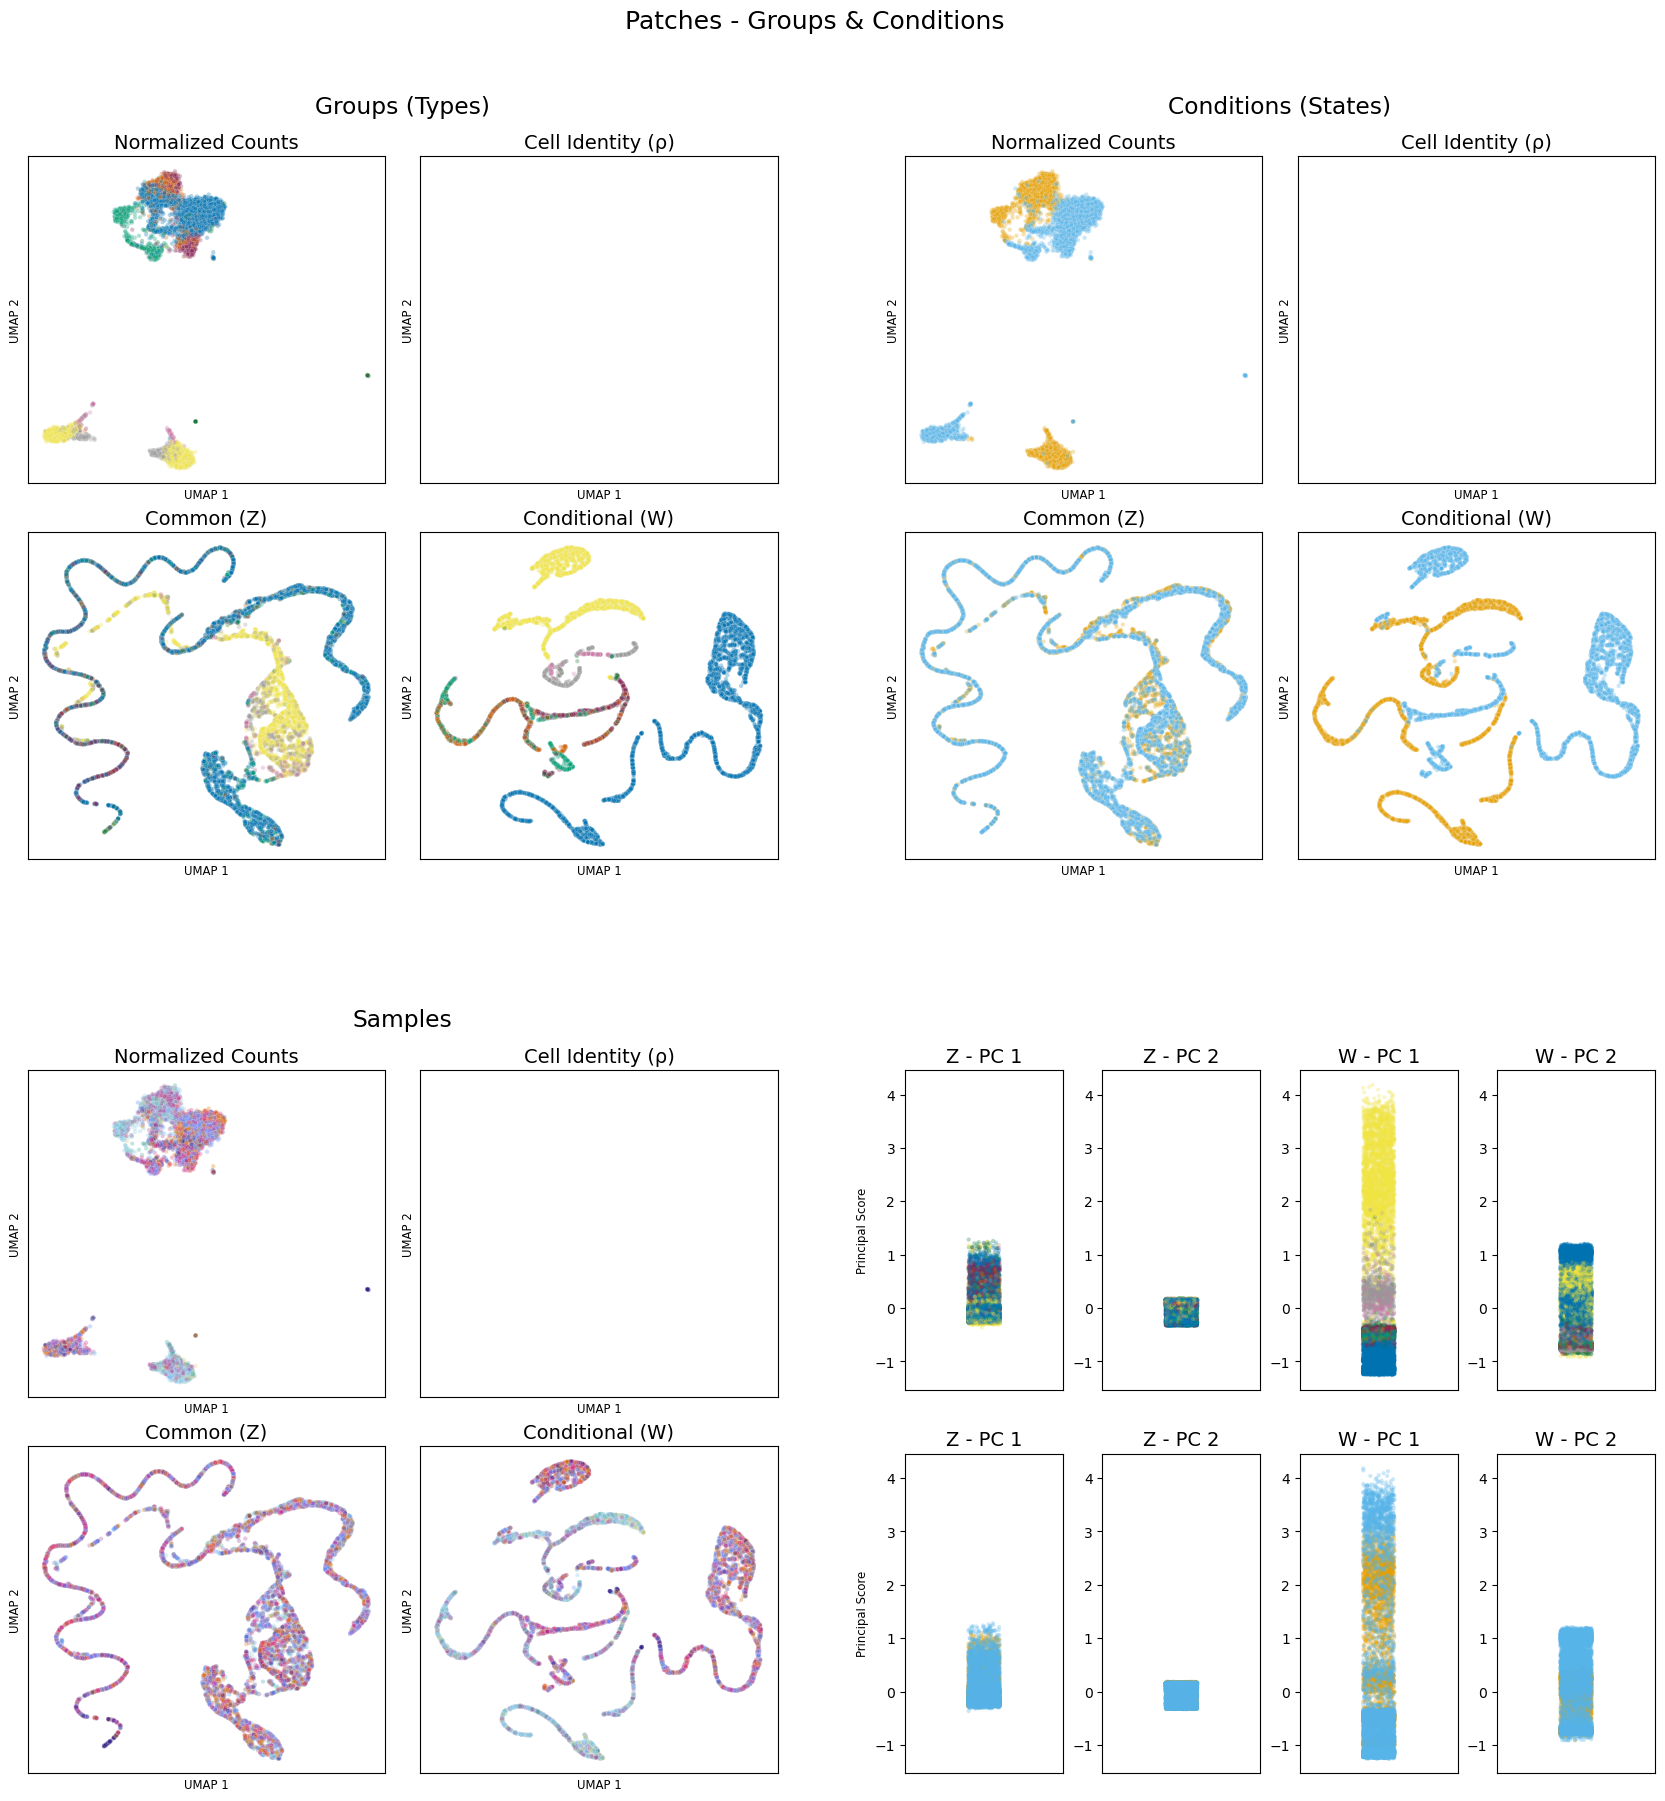

In [20]:
# Figure skeleton (adapted from Patches tutorial docs)


## color palettes
klee_palette = [
    "#8B1E3F",  # Deep Burgundy
    "#3B5998",  # Rich Blue
    "#F4A261",  # Warm Orange
    "#264653",  # Deep Teal
    "#E9C46A",  # Soft Yellow
    "#2A9D8F",  # Muted Green
    "#E76F51",  # Burnt Sienna
    "#D3D9E3",  # Soft Pastel Blue
    "#A8DADC",  # Pale Turquoise
    "#BC4749",  # Warm Cranberry Red
]

klee_palette_masch = [
    "#3B5998",  # Rich Blue
    "#6A994E",  # Fresh Olive Green
    "#F4A261",  # Warm Orange
    "#E9C46A",  # Soft Yellow
    "#2A9D8F",  # Muted Green
    "#E76F51",  # Burnt Sienna
    "#FFC8A2",  # Soft Peach
    "#A8DADC",  # Pale Turquoise
    "#BC4749",  # Warm Cranberry Red
]

cbf_palette = [
    "#E69F00",  # Orange
    "#56B4E9",  # Sky Blue
    "#009E73",  # Bluish Green
    "#F0E442",  # Yellow
    "#0072B2",  # Blue
    "#D55E00",  # Vermillion
    "#CC79A7",  # Reddish Purple
    "#999999",  # Gray
    "#117733",  # Dark Green
    "#882255",  # Wine
    "#44AA99",  # Teal
    "#DDCC77",  # Sand
    "#88CCEE",  # Light Blue
    "#AA4499",  # Magenta
    "#332288",  # Navy
    "#E17C05",  # Burnt Orange
    "#DC267F",  # Pink
    "#648FFF",  # Vivid Blue
    "#785EF0",  # Violet
    "#FE6100",  # Bright Orange
]


## plot parameters
fontsize=14
alpha=0.3
s=10
s_pca=3


## create a figure with a 2x2 grid of subplots
fig = plt.figure(figsize=(21, 21))

## define a GridSpec with a 2x2 layout
gs = gridspec.GridSpec(2, 2, wspace=0.17, hspace = 0.3, figure=fig)

## create subplots for the 2x2 grid
ax = [fig.add_subplot(gs[i//2, i%2]) for i in range(4)]

for subax in ax:
    subax.axis('off')

## define a new GridSpec for axis to split vertically
gs_inner_topleft = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 0], wspace=0.1, hspace=0.15)
gs_inner_topright = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], wspace=0.1, hspace=0.15)
gs_inner_botleft = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1, 0], wspace=0.1, hspace=0.15)
gs_inner_botright = gridspec.GridSpecFromSubplotSpec(2, 4, subplot_spec=gs[1, 1], wspace=0.25)

## create subplots for the inner grid
ax_inner_topleft = [fig.add_subplot(gs_inner_topleft[i//2, i%2]) for i in range(4)]
ax_inner_topright = [fig.add_subplot(gs_inner_topright[i//2, i%2]) for i in range(4)]
ax_inner_botleft = [fig.add_subplot(gs_inner_botleft[i//2, i%2]) for i in range(4)]

## specific for botright
ax_inner_botright = [fig.add_subplot(gs_inner_botright[0,0])]
ax_inner_botright = ax_inner_botright \
+ [
    fig.add_subplot(gs_inner_botright[0,1],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[0,2],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[0,3],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,0],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,1],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,2],sharey=ax_inner_botright[0]),
    fig.add_subplot(gs_inner_botright[1,3],sharey=ax_inner_botright[0]),
]


## UMAP plots

### counts
clu = sns.scatterplot(df_base, x='base_umap_1', y='base_umap_2', ax=ax_inner_topright[0], hue = 'group_id', palette=sns.color_palette(cbf_palette[0:2]), s=s, alpha=alpha)
con = sns.scatterplot(df_base, x='base_umap_1', y='base_umap_2', ax=ax_inner_topleft[0], hue = 'cluster_id', palette=sns.color_palette(cbf_palette[2:10]), s=s, alpha=alpha)
sam = sns.scatterplot(df_base, x='base_umap_1', y='base_umap_2', ax=ax_inner_botleft[0], hue = 'sample_id', palette=sns.color_palette(cbf_palette[10:18]), s=s, alpha=alpha)

### Zs
sns.scatterplot(df_patches, x='z_umap_1', y='z_umap_2', ax=ax_inner_topright[2], hue = 'group_id', palette=sns.color_palette(cbf_palette[0:2]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='z_umap_1', y='z_umap_2', ax=ax_inner_topleft[2], hue = 'cluster_id', palette=sns.color_palette(cbf_palette[2:10]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='z_umap_1', y='z_umap_2', ax=ax_inner_botleft[2], hue = 'sample_id', palette=sns.color_palette(cbf_palette[10:18]), s=s, alpha=alpha, legend=False)

### Ws
sns.scatterplot(df_patches, x='w_umap_1', y='w_umap_2', ax=ax_inner_topright[3], hue = 'group_id', palette=sns.color_palette(cbf_palette[0:2]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='w_umap_1', y='w_umap_2', ax=ax_inner_topleft[3], hue = 'cluster_id', palette=sns.color_palette(cbf_palette[2:10]), s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches, x='w_umap_1', y='w_umap_2', ax=ax_inner_botleft[3], hue = 'sample_id', palette=sns.color_palette(cbf_palette[10:18]), s=s, alpha=alpha, legend=False)


## PCA plots

### cluster
sns.stripplot(df_patches, y = "z_pc_1", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[0], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[0].axvline(zorder=2, color='black', linestyle = 'dashed')
    
sns.stripplot(df_patches, y = "z_pc_2", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[1], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[1].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_1", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[2], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[2].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_2", hue='cluster_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[3], legend=False, palette=sns.color_palette(cbf_palette[2:10]))
#ax_inner_botright[3].axvline(zorder=2, color='black', linestyle = 'dashed')


### condition
sns.stripplot(df_patches, y = "z_pc_1", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[4], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[4].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "z_pc_2", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[5], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[5].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_1", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[6], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[6].axvline(zorder=2, color='black', linestyle = 'dashed')

sns.stripplot(df_patches, y = "w_pc_2", hue='group_id', zorder=1, alpha=alpha, s=s_pca, ax=ax_inner_botright[7], legend=False, palette=sns.color_palette(cbf_palette[0:2]))
#ax_inner_botright[7].axvline(zorder=2, color='black', linestyle = 'dashed')


## formatting

for subax in ax_inner_topright:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_yticklabels([])
    subax.set_yticks([])
    subax.set_xlabel('UMAP 1', fontsize=fontsize*0.6)
    subax.set_ylabel('UMAP 2', fontsize=fontsize*0.6)
    try:
        force_aspect(subax)
    except:
        pass

for subax in ax_inner_topleft:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_yticklabels([])
    subax.set_yticks([])
    subax.set_xlabel('UMAP 1', fontsize=fontsize*0.6)
    subax.set_ylabel('UMAP 2', fontsize=fontsize*0.6)
    try:
        force_aspect(subax)
    except:
        pass

for subax in ax_inner_botleft:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_yticklabels([])
    subax.set_yticks([])
    subax.set_xlabel('UMAP 1', fontsize=fontsize*0.6)
    subax.set_ylabel('UMAP 2', fontsize=fontsize*0.6)
    try:
        force_aspect(subax)
    except:
        pass

for subax in ax_inner_botright:
    subax.set_xticklabels([])
    subax.set_xticks([])
    subax.set_xlabel('')
    subax.set_ylabel('')

ax_inner_botright[0].set_ylabel('Principal Score', fontsize=fontsize*0.6)
ax_inner_botright[4].set_ylabel('Principal Score', fontsize=fontsize*0.6)

clu_h, clu_l = clu.get_legend_handles_labels() 
con_h, con_l = con.get_legend_handles_labels()
sam_h, sam_l = sam.get_legend_handles_labels()

clu.legend([], frameon=False); con.legend([], frameon=False); sam.legend([], frameon=False)

ax_inner_topleft[0].set_title('Normalized Counts', fontsize=fontsize)
ax_inner_topleft[1].set_title('Cell Identity (ρ)', fontsize=fontsize)
ax_inner_topleft[2].set_title('Common (Z)', fontsize=fontsize)
ax_inner_topleft[3].set_title('Conditional (W)', fontsize=fontsize)

ax_inner_topright[0].set_title('Normalized Counts', fontsize=fontsize)
ax_inner_topright[1].set_title('Cell Identity (ρ)', fontsize=fontsize)
ax_inner_topright[2].set_title('Common (Z)', fontsize=fontsize)
ax_inner_topright[3].set_title('Conditional (W)', fontsize=fontsize)

ax_inner_botleft[0].set_title('Normalized Counts', fontsize=fontsize)
ax_inner_botleft[1].set_title('Cell Identity (ρ)', fontsize=fontsize)
ax_inner_botleft[2].set_title('Common (Z)', fontsize=fontsize)
ax_inner_botleft[3].set_title('Conditional (W)', fontsize=fontsize)

ax_inner_botright[0].set_title('Z - PC 1', fontsize=fontsize)
ax_inner_botright[1].set_title('Z - PC 2', fontsize=fontsize)
ax_inner_botright[2].set_title('W - PC 1', fontsize=fontsize)
ax_inner_botright[3].set_title('W - PC 2', fontsize=fontsize)
ax_inner_botright[4].set_title('Z - PC 1', fontsize=fontsize)
ax_inner_botright[5].set_title('Z - PC 2', fontsize=fontsize)
ax_inner_botright[6].set_title('W - PC 1', fontsize=fontsize)
ax_inner_botright[7].set_title('W - PC 2', fontsize=fontsize)


## set subplot titles
titles = ['Groups (Types)', 'Conditions (States)', 'Samples', '']

for a, t in zip(ax, titles):
    a.set_title(t, y=1.05, fontsize=fontsize*1.2)


## save and show figure
fig.suptitle("Patches - Groups & Conditions", fontsize=18, y=0.95)
plt.savefig("../../outs/kang/Kang18-patches_clu_con.png", dpi=300, bbox_inches='tight')
plt.show()